# Load datasets
Load each CSV into a separate pandas DataFrame: `train_dataset`, `test_dataset`, and `metadata_dataset`.

In [7]:
from pathlib import Path
import pandas as pd

# Support running from the project root or this notebook's folder.
data_dir = Path("enr-4320-ms")
if not data_dir.is_dir():
    data_dir = Path("Semi_Seismic_Type") / "enr-4320-ms"

# Store each CSV as a separate pandas DataFrame.
train_dataset = pd.read_csv(data_dir / "train.csv")
test_dataset = pd.read_csv(data_dir / "test.csv")
metadata_dataset = pd.read_csv(data_dir / "metadata.csv")

for name, dataset in [("train", train_dataset), ("test", test_dataset), ("metadata", metadata_dataset)]:
    print(f"{name}: {dataset.shape[0]} rows, {dataset.shape[1]} columns")


train: 3375 rows, 8 columns
test: 844 rows, 7 columns
metadata: 9 rows, 6 columns


In [8]:
metadata_dataset

,column_name,role,data_type,unit,description,valid_values_or_mapping
0,ID,identifier,integer,NaN,Unique row identifier.,Positive integer
1,Duration,feature,float,s,Time interval from the initial threshold cross...,NaN
2,Rising_time,feature,float,s,Time interval from the initial threshold cross...,NaN
3,Absolute_amplitude,feature,float,mV,Maximum absolute amplitude of the recorded sig...,NaN
4,Relative_amplitude,feature,float,dimensionless,Ratio of the maximum absolute amplitude to the...,NaN
5,Pseudo_energy,feature,float,mV·s,Pseudo-energy attribute derived from the absol...,NaN
6,Pseudo_freq,feature,float,s^-1,Pseudo-frequency attribute derived from signal...,NaN
7,Label,training target,categorical string,NaN,Signal class provided in train.csv. Participan...,microseismic; blasting; drilling; scaling; ele...
8,Class,submission target,integer,NaN,Integer class label required in sample_submiss...,0=Microseismic; 1=Blasting; 2=Drilling; 3=Scal...


In [9]:
train_dataset

,ID,Duration,Rising_time,Absolute_amplitude,Relative_amplitude,Pseudo_energy,Pseudo_freq,Label
0,1,0.488282,0.048906,87.319443,0.019629,0.099501,540.671692,drilling
1,2,0.443321,0.081856,54.576271,0.076005,0.025697,279.707306,scaling
2,3,0.016250,0.005723,57.395706,0.543220,0.003595,2153.844971,microseismic
3,4,0.050586,0.004277,64.888947,0.283787,0.006882,355.829926,microseismic
4,5,0.285449,0.169414,169.013840,0.033295,0.058662,126.116928,blasting
...,...,...,...,...,...,...,...,...
3370,3371,0.011406,0.002969,330.973999,0.784962,0.002488,2717.806885,microseismic
3371,3372,0.378184,0.000176,475.284912,0.214451,0.009108,7.932651,electric noise
3372,3373,0.420547,0.192988,82.400215,0.100709,0.019394,149.804855,scaling
3373,3374,0.011563,0.001934,256.248444,0.736836,0.002651,3113.511963,microseismic


# Encoding on non-Integers

In Label, it does have non-numeric labels, so we need to see what are the values in Label and label as Numeric Value

0=Microseismic; 1=Blasting; 2=Drilling; 3=Scaling; 4=Electrical Noise

In [10]:
label_mapping = {
    "drilling": 2,
    "microseismic": 0,
    "blasting": 1,
    "electric noise": 4,
    "scaling": 3,
}

train_dataset_label_encoding = train_dataset.copy()

labels = (
    train_dataset["Label"]
    .astype("string")
    .str.strip()
    .str.lower()
)

unknown_labels = labels[
    labels.notna() & ~labels.isin(label_mapping)
].unique()

if len(unknown_labels):
    raise ValueError(f"Unknown labels found: {unknown_labels.tolist()}")

train_dataset_label_encoding["Label"] = labels.map(label_mapping).astype("Int64")

print(train_dataset_label_encoding["Label"].value_counts(dropna=False).sort_index())

Label
0    349
1    713
2    825
3    843
4    645
Name: count, dtype: Int64


# Data Type Recognition

In [11]:
# Show the data type of each feature.
print(train_dataset_label_encoding.dtypes)

ID                      int64
Duration              float64
Rising_time           float64
Absolute_amplitude    float64
Relative_amplitude    float64
Pseudo_energy         float64
Pseudo_freq           float64
Label                   Int64
dtype: object


Except ID, all features would be numerical continuous values

Whilst Label is Numeric Categorization Values

# Visualizing

Numeric features: ['Duration', 'Rising_time', 'Absolute_amplitude', 'Relative_amplitude', 'Pseudo_energy', 'Pseudo_freq']


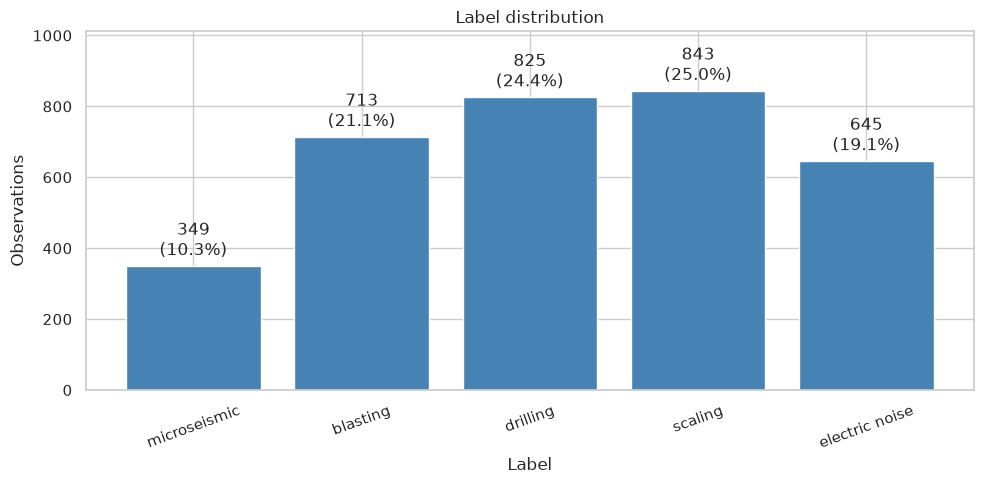

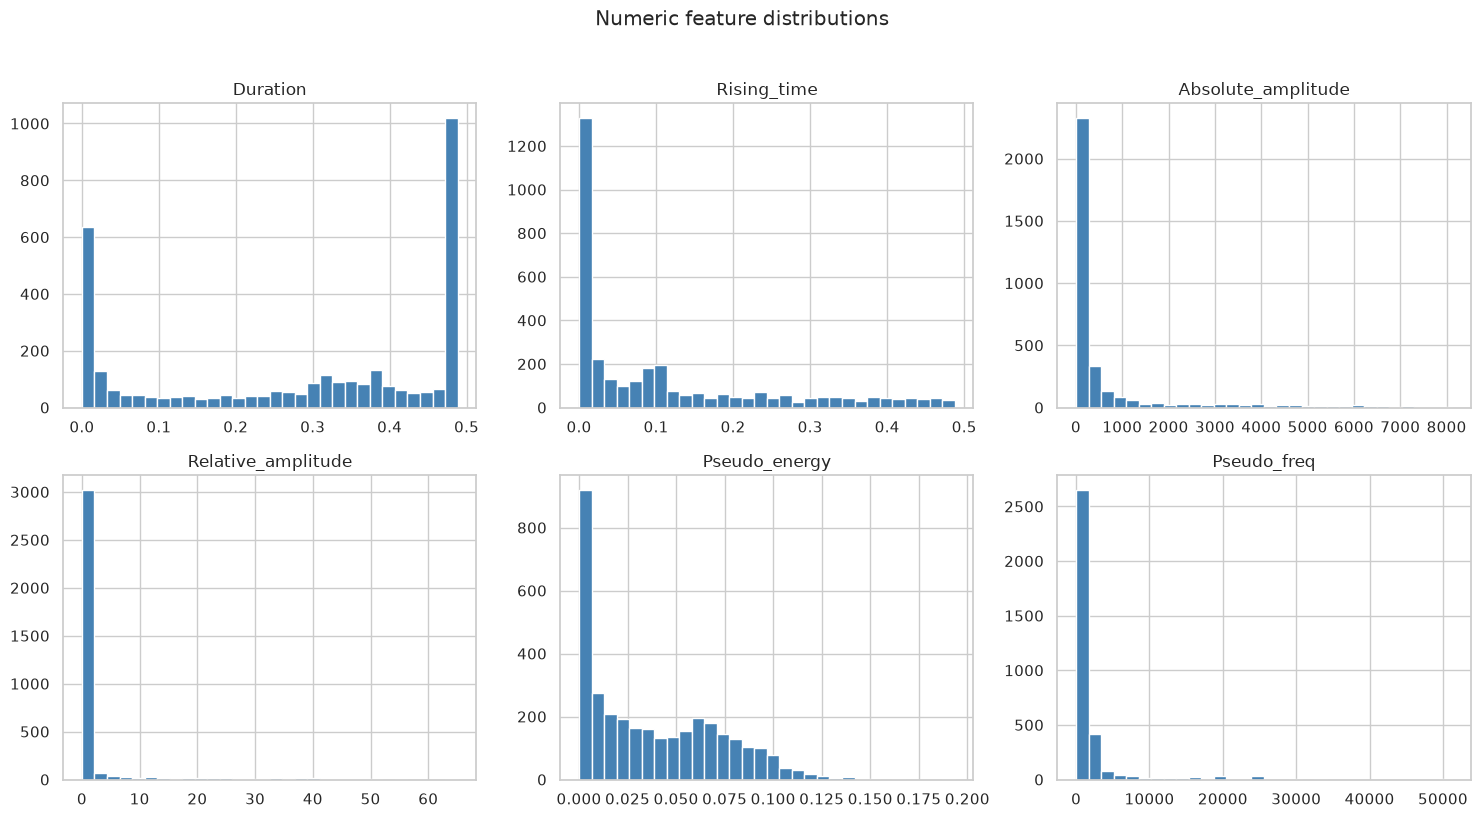

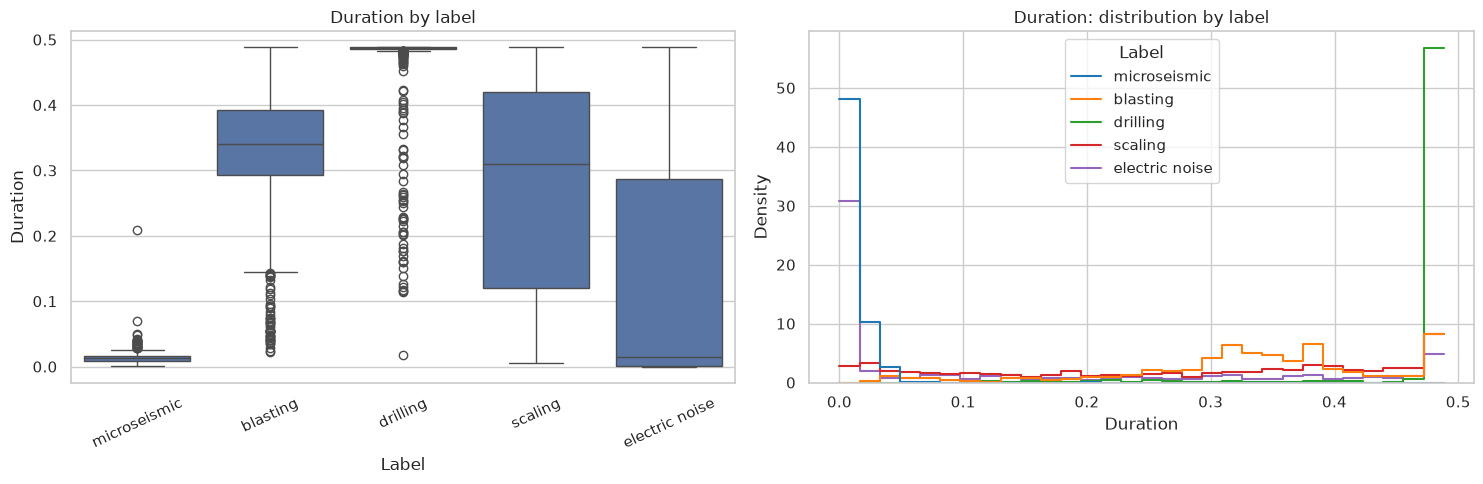

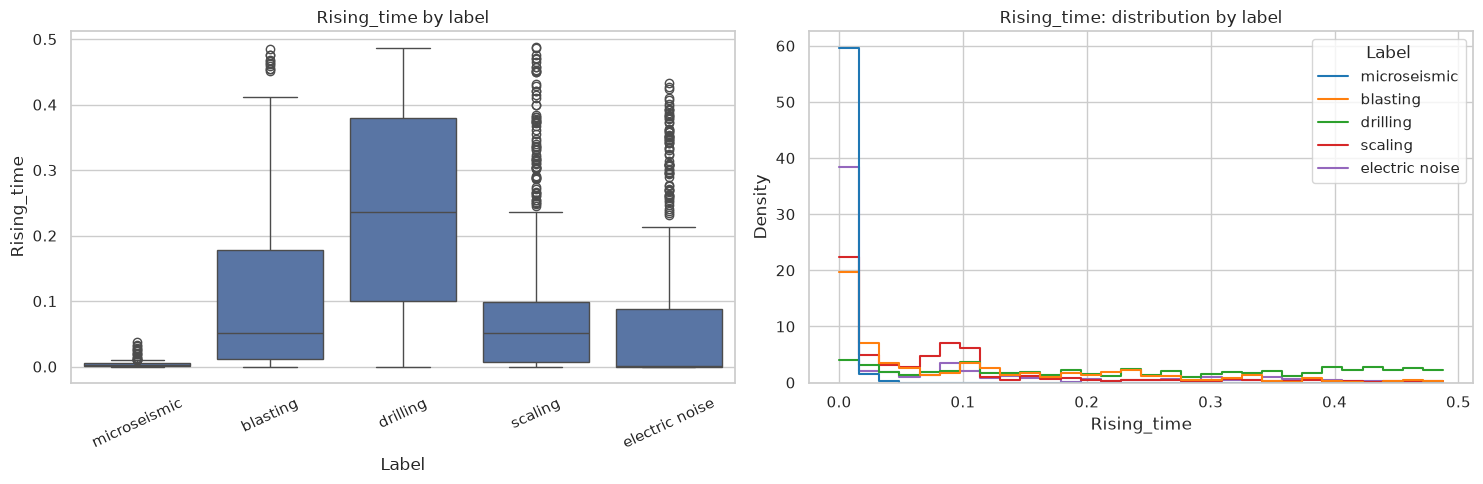

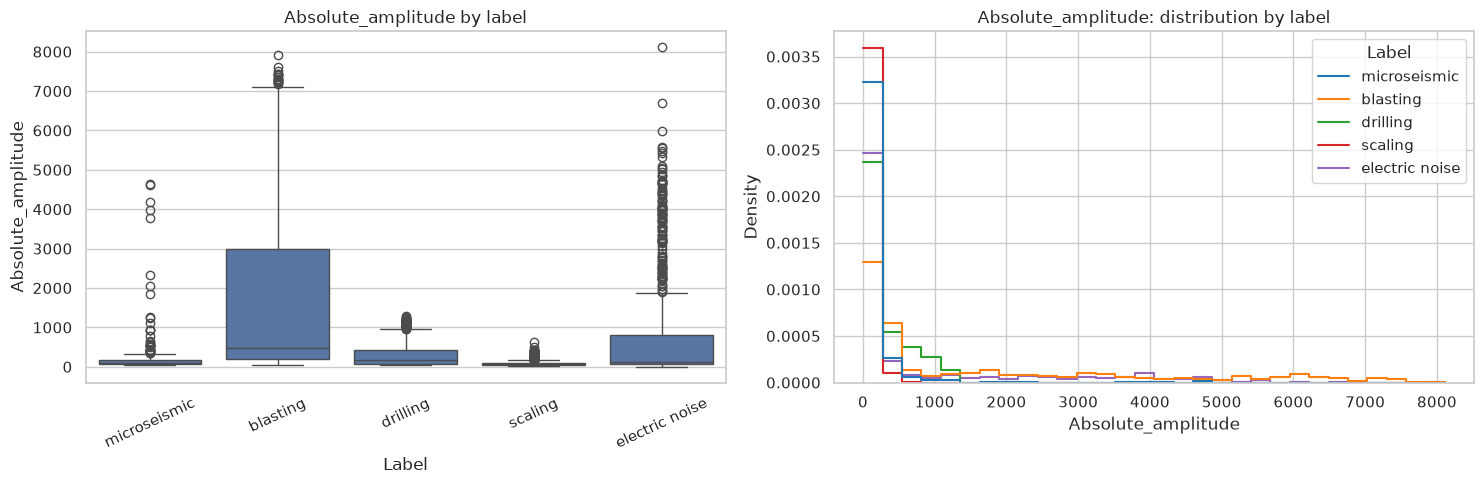

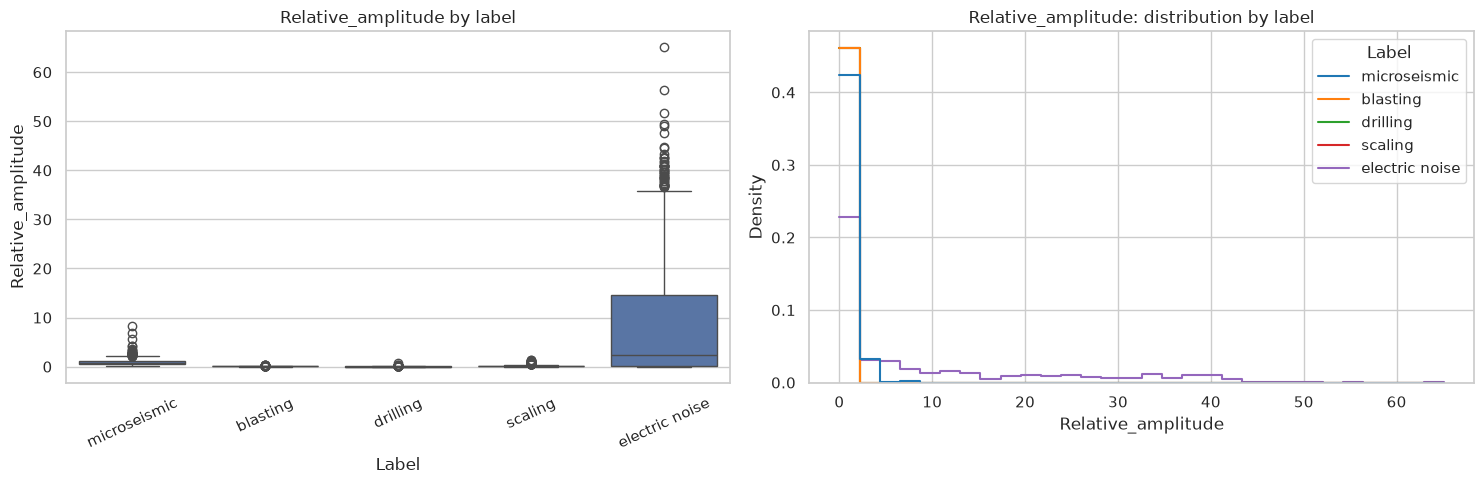

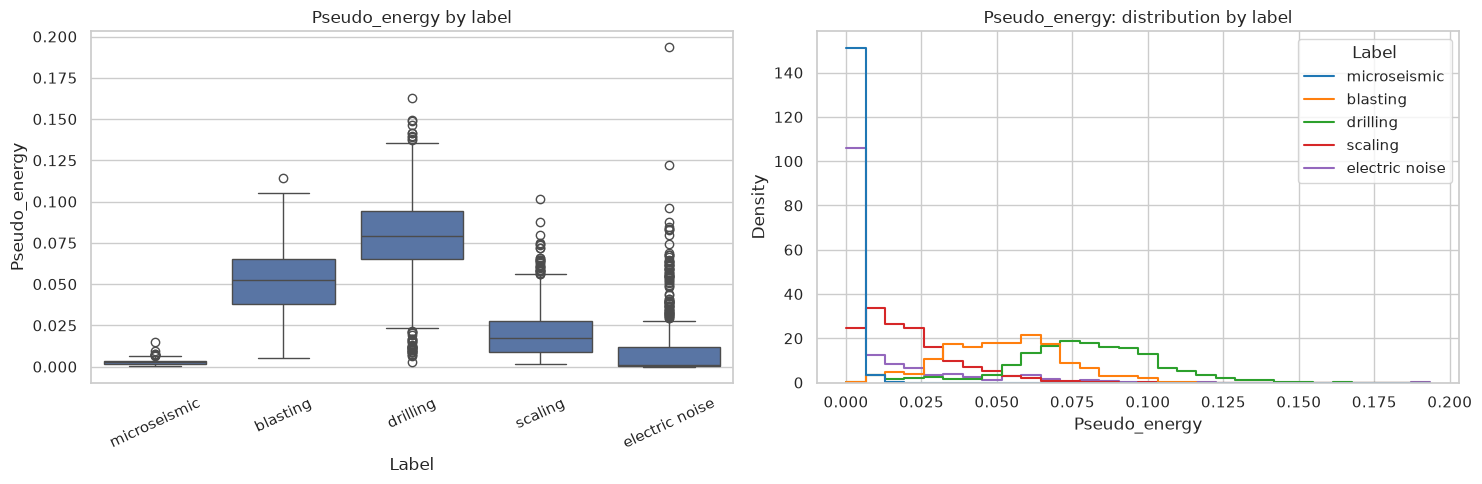

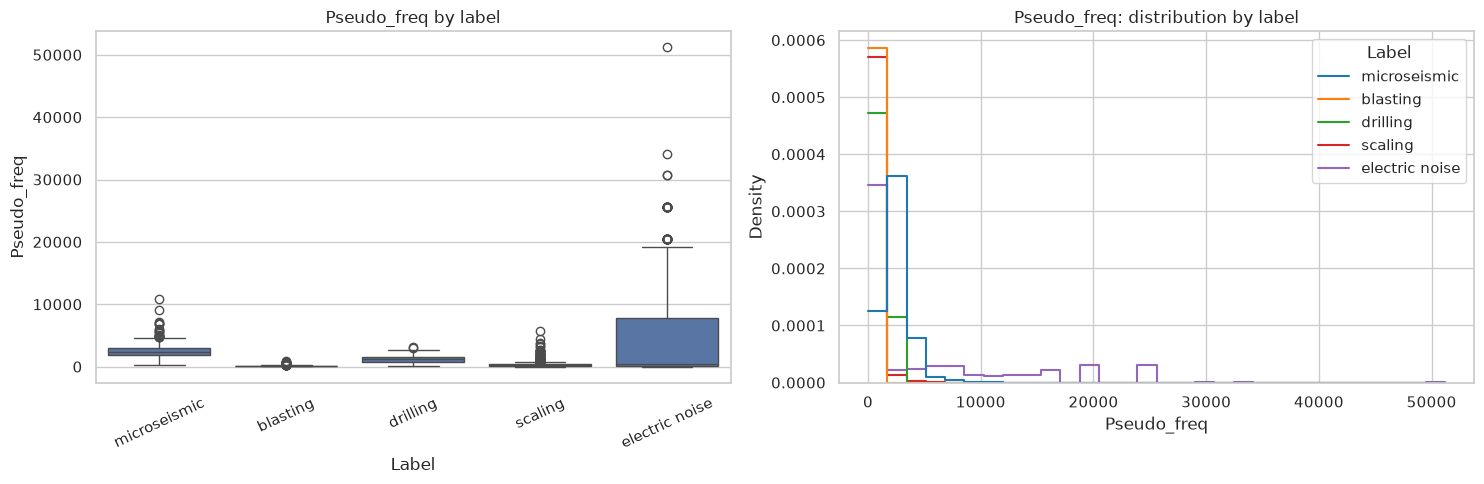

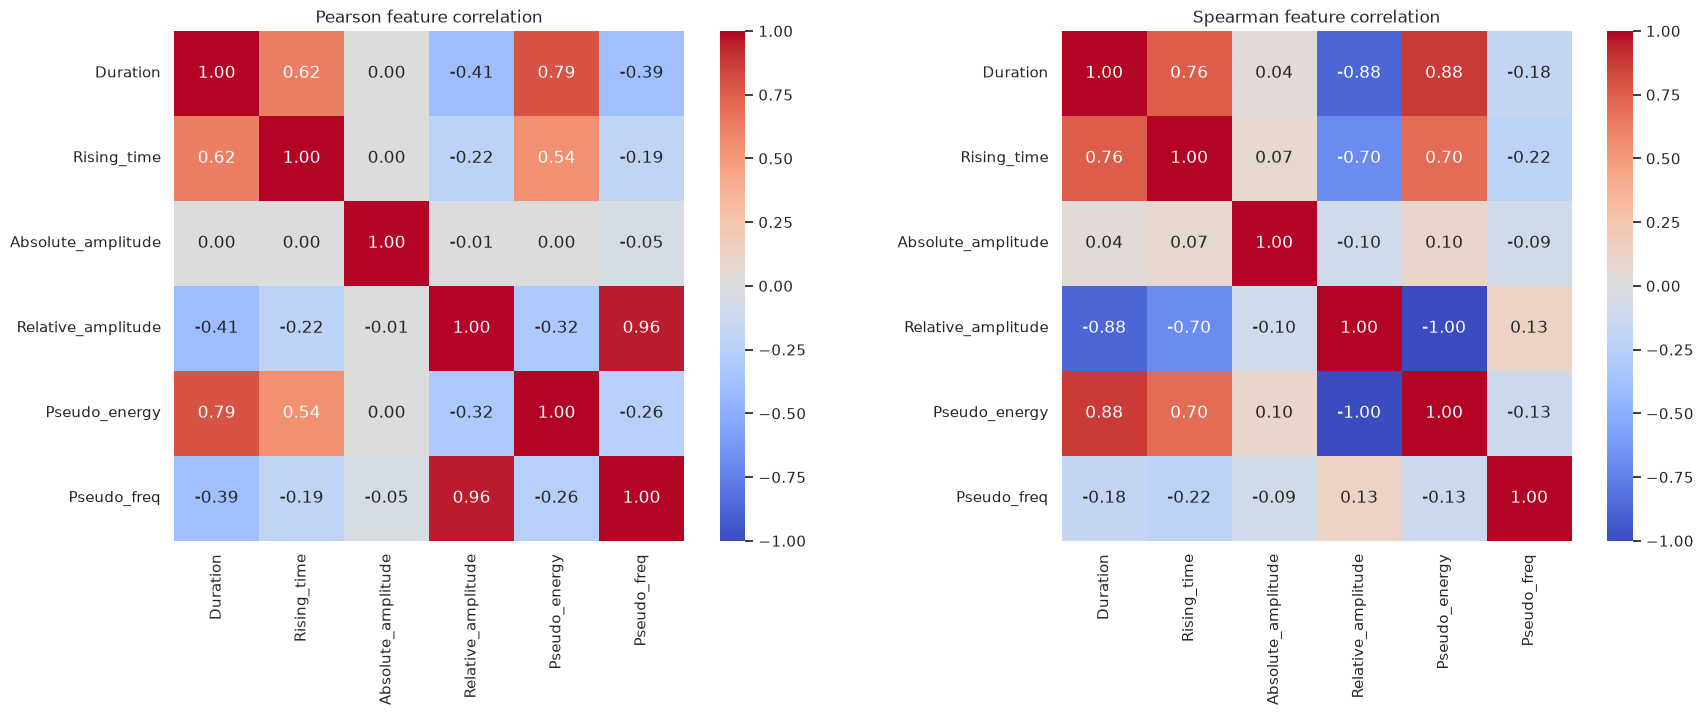

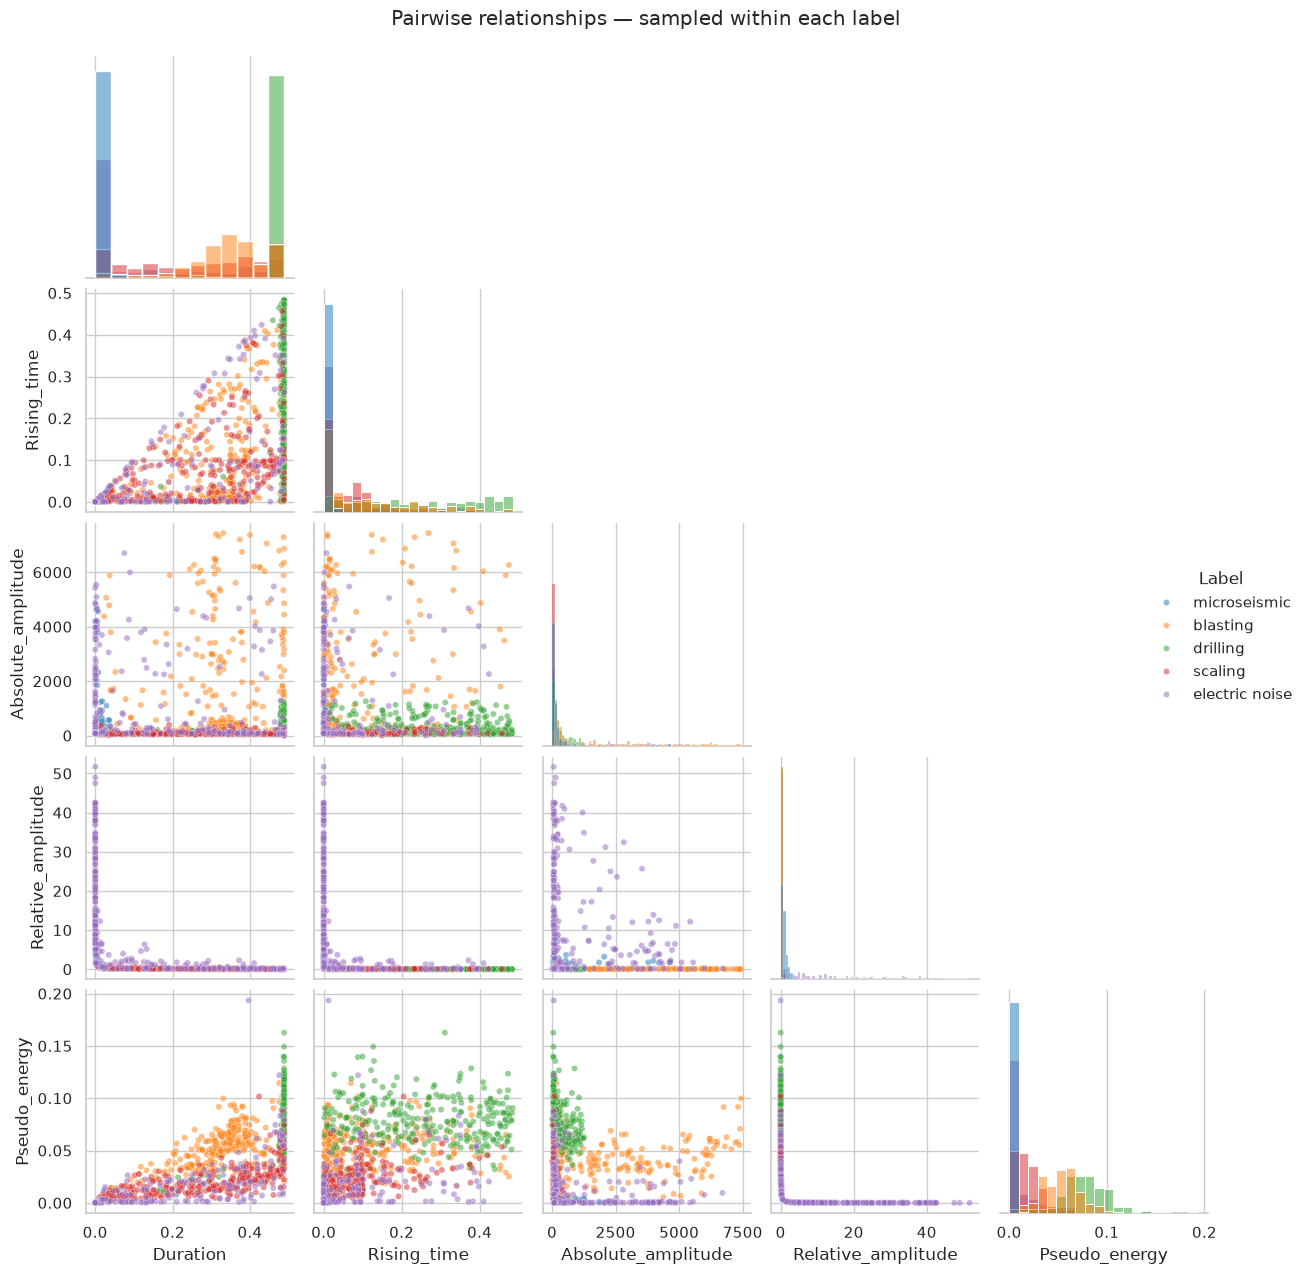

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

eda = train_dataset_label_encoding.copy()

# Display names only; Label values remain unchanged.
label_names = {
    0: "microseismic",
    1: "blasting",
    2: "drilling",
    3: "scaling",
    4: "electric noise",
}
label_order = list(label_names)

# Add any other identifier columns here.
exclude_columns = {"Label", "record_number", "sample_code"}

numeric_features = []

for column in eda.columns:
    normalized_name = re.sub(
        r"([a-z0-9])([A-Z])", r"\1_\2", str(column)
    )
    name_parts = re.split(r"[\s_\-]+", normalized_name.lower())

    if column in exclude_columns or "id" in name_parts:
        continue

    original = eda[column]

    if (
        pd.api.types.is_bool_dtype(original)
        or pd.api.types.is_datetime64_any_dtype(original)
        or pd.api.types.is_timedelta64_dtype(original)
    ):
        continue

    converted = pd.to_numeric(original, errors="coerce")

    if original.notna().any() and converted[original.notna()].notna().all():
        eda[column] = converted.replace([np.inf, -np.inf], np.nan)
        numeric_features.append(column)

print("Numeric features:", numeric_features)

# 1. Label distribution
counts = eda["Label"].value_counts().reindex(label_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [label_names[label] for label in counts.index],
    counts.values,
    color="steelblue",
)

for bar, count in zip(bars, counts.values):
    percentage = count / counts.sum() * 100 if counts.sum() else 0
    ax.annotate(
        f"{count:,}\n({percentage:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )

ax.set(title="Label distribution", xlabel="Label", ylabel="Observations")
ax.margins(y=0.2)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 2. Overall numeric feature distributions
if numeric_features:
    rows = (len(numeric_features) + 2) // 3
    eda[numeric_features].hist(
        bins=30,
        figsize=(15, 4 * rows),
        layout=(rows, 3),
        color="steelblue",
        edgecolor="white",
    )
    plt.suptitle("Numeric feature distributions", y=1.02)
    plt.tight_layout()
    plt.show()

# 3. Boxplots and distributions by label
for feature in numeric_features:
    if eda[feature].notna().sum() == 0:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.boxplot(
        data=eda,
        x="Label",
        y=feature,
        order=label_order,
        ax=axes[0],
    )
    axes[0].set_xticks(
        range(len(label_order)),
        labels=[label_names[label] for label in label_order],
        rotation=25,
    )
    axes[0].set(
        title=f"{feature} by label",
        xlabel="Label",
        ylabel=feature,
    )

    sns.histplot(
        data=eda,
        x=feature,
        hue="Label",
        hue_order=label_order,
        palette="tab10",
        bins=30,
        stat="density",
        common_norm=False,
        common_bins=True,
        element="step",
        fill=False,
        ax=axes[1],
    )
    axes[1].set(title=f"{feature}: distribution by label")

    legend = axes[1].get_legend()
    if legend is not None:
        for text, label in zip(legend.get_texts(), label_order):
            text.set_text(label_names[label])

    plt.tight_layout()
    plt.show()

# 4. Pearson and Spearman correlations (exclude categorical Label)
varying_features = [
    feature for feature in numeric_features
    if eda[feature].nunique() > 1
]

if len(varying_features) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, method in zip(axes, ["pearson", "spearman"]):
        sns.heatmap(
            eda[varying_features].corr(method=method),
            annot=len(varying_features) <= 12,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            ax=ax,
        )
        ax.set_title(f"{method.title()} feature correlation")

    plt.tight_layout()
    plt.show()

# 5. Pairwise relationships: up to five features, sampled per label
selected_features = varying_features[:5]

if len(selected_features) >= 2:
    pair_data = eda.dropna(subset=selected_features + ["Label"])

    sampled_groups = [
        group.sample(n=min(len(group), 300), random_state=42)
        for _, group in pair_data.groupby("Label")
    ]

    if sampled_groups:
        pair_sample = pd.concat(sampled_groups, ignore_index=True)

        grid = sns.pairplot(
            pair_sample,
            vars=selected_features,
            hue="Label",
            hue_order=label_order,
            palette="tab10",
            diag_kind="hist",
            corner=True,
            plot_kws={"alpha": 0.5, "s": 20},
        )

        if grid.legend is not None:
            for text, label in zip(grid.legend.get_texts(), label_order):
                text.set_text(label_names[label])

        grid.fig.suptitle(
            "Pairwise relationships — sampled within each label",
            y=1.02,
        )
        plt.show()

In [13]:
# Saving Encoded Train Dataset
train_dataset_label_encoding.to_csv("enr-4320-ms/train_encoded.csv", index=False)